# 04 · Exploratory data analysis: all 60 products (Task 3)

Reads the cleaned and aligned tables built by the pipeline:
- `data/processed/aligned_daily.csv`
- `full_report.csv` and `alignment_report.csv`
- `youtube_product_daily_clean.csv`, `youtube_videos_clean.csv` and `youtube_comments_clean.csv`

It describes the data only. **No model features and no surge label are built here.**

Every chart has a business question above it. A **Findings** cell below it is computed from the data when the notebook runs, so the text stays true after the tables are rebuilt.

Read before interpreting:
- **Relative scales.** Each product's Google Trends series is scaled to its own peak (= 100), so levels are not comparable across products in absolute terms.
- **pytrends zeros.** Values are integers, so a "<1" day is stored as 0.
- **Provisional last day.** The last Trends day (`is_provisional`) may still be revised by Google. It is excluded from the distributions and trends below.
- **Thin YouTube overlap.** YouTube has only one or two snapshots per product. Its overlap with the Trends window is very thin (chart 8).

Charts are saved to `docs/figures/eda_full_*.png`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
import pandas as pd
from IPython.display import Markdown, display

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
P = ROOT / "data" / "processed"
FIGURES = ROOT / "docs" / "figures"
FIGURES.mkdir(parents=True, exist_ok=True)
TYPES = ["RISING", "STABLE", "DECLINING"]
COLORS = {"RISING": "#d1495b", "STABLE": "#2e86ab", "DECLINING": "#8d8d8d"}
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})


def load(name, **kw):
    path = P / name
    if not path.exists():
        print(f"missing input: {path.relative_to(ROOT)}")
        return pd.DataFrame()
    return pd.read_csv(path, **kw)


def has(df, *cols):
    missing = [c for c in cols if c not in df.columns]
    if df.empty or missing:
        print(f"skipped: needed columns not available {missing or '(empty table)'}")
        return False
    return True


def save(fig, name):
    fig.tight_layout()
    fig.savefig(FIGURES / name, bbox_inches="tight")
    plt.show()


def findings(*lines):
    display(Markdown("**Findings**\n\n" + "\n".join(f"- {line}" for line in lines)))


aligned = load("aligned_daily.csv", parse_dates=["date"])
report = load("full_report.csv")
coverage = load("alignment_report.csv")
daily = load("youtube_product_daily_clean.csv")
videos = load("youtube_videos_clean.csv")
comments = load("youtube_comments_clean.csv")

if not aligned.empty and "is_provisional" in aligned:
    complete = aligned[~aligned["is_provisional"].astype(bool) & aligned["search_interest"].notna()].copy()
else:
    complete = aligned.copy()
latest_comments = comments
if has(comments, "snapshot_date", "product_id"):
    latest_comments = comments[comments["snapshot_date"] == comments.groupby("product_id")["snapshot_date"].transform("max")]
print(f"aligned rows {len(aligned)}, products {aligned['product_id'].nunique() if not aligned.empty else 0}; "
      f"report rows {len(report)}; videos {len(videos)}; comments {len(comments)} (latest snapshot {len(latest_comments)})")

aligned rows 16140, products 60; report rows 60; videos 3500; comments 32215 (latest snapshot 27576)


## 1. Zero-share per product

**Business question:** for which products is Google Trends too sparse to carry a demand signal?

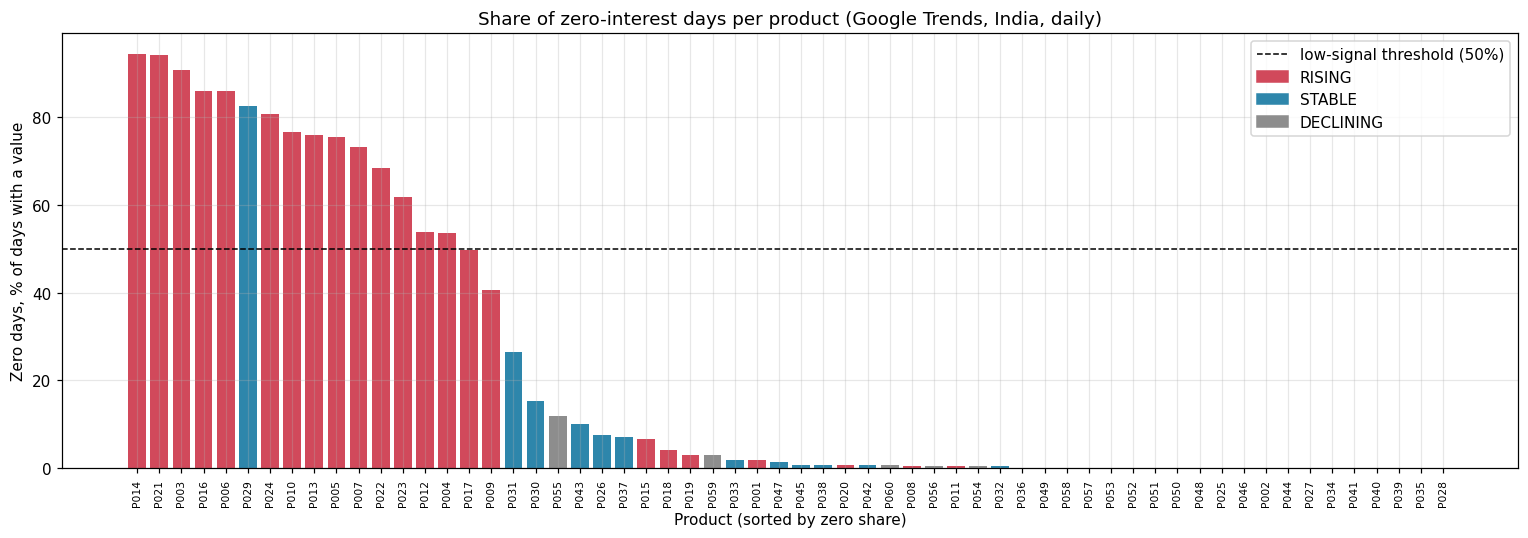

**Findings**

- 15 of 60 products have more than 50% zero days and are flagged `low_signal_product`; 14 of them are RISING (mostly launched inside the window, so their series is zero before launch).
- Highest zero shares: P014 94%, P021 94%, P003 91%, P016 86%, P006 86%.
- 20 products have no zero day at all.

In [2]:
if has(report, "product_id", "zero_share", "product_type"):
    z = report.dropna(subset=["zero_share"]).sort_values("zero_share", ascending=False)
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.bar(z["product_id"], z["zero_share"] * 100, color=[COLORS.get(t, "black") for t in z["product_type"]])
    line = ax.axhline(50, color="black", ls="--", lw=1, label="low-signal threshold (50%)")
    handles = [line] + [Patch(color=COLORS[t], label=t) for t in TYPES]
    ax.set_title("Share of zero-interest days per product (Google Trends, India, daily)")
    ax.set_xlabel("Product (sorted by zero share)")
    ax.set_ylabel("Zero days, % of days with a value")
    ax.tick_params(axis="x", rotation=90, labelsize=7)
    ax.legend(handles=handles)
    save(fig, "eda_full_01_zero_share.png")
    low = z[z["zero_share"] > 0.5]
    findings(f"{len(low)} of {len(z)} products have more than 50% zero days and are flagged `low_signal_product`; "
             f"{(low['product_type'] == 'RISING').sum()} of them are RISING (mostly launched inside the window, so "
             f"their series is zero before launch).",
             f"Highest zero shares: " + ", ".join(f"{r.product_id} {r.zero_share:.0%}" for r in low.head(5).itertuples()) + ".",
             f"{(z['zero_share'] == 0).sum()} products have no zero day at all.")

## 2. Distribution of search interest

**Business question:** what does a typical day of search interest look like, and how does it differ by product type?

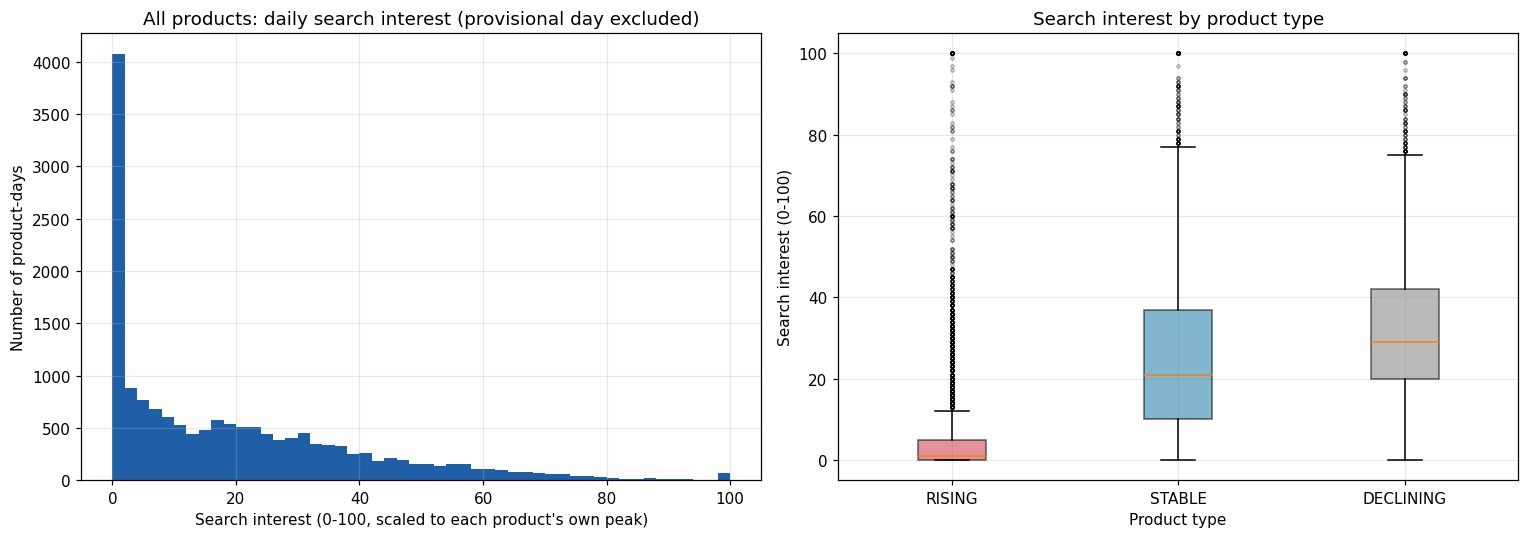

**Findings**

- 16,080 product-days: 23% are zero; the median is 14 and only 1.7% of days are at 75 or above (peaks are rare by construction).
- Median by type: RISING 1 (49% zero days), STABLE 21 (6% zero days), DECLINING 29 (1% zero days).
- Because each series is scaled to its own peak, a low typical level means a spiky series, not low demand.

In [3]:
if has(complete, "search_interest", "product_type"):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(complete["search_interest"], bins=np.arange(0, 102, 2), color="#1f5fa8")
    axes[0].set_title("All products: daily search interest (provisional day excluded)")
    axes[0].set_xlabel("Search interest (0-100, scaled to each product's own peak)")
    axes[0].set_ylabel("Number of product-days")
    data = [complete.loc[complete["product_type"] == t, "search_interest"] for t in TYPES]
    bp = axes[1].boxplot(data, tick_labels=TYPES, patch_artist=True, flierprops={"markersize": 2, "alpha": 0.3})
    for patch, t in zip(bp["boxes"], TYPES):
        patch.set_facecolor(COLORS[t])
        patch.set_alpha(0.6)
    axes[1].set_title("Search interest by product type")
    axes[1].set_xlabel("Product type")
    axes[1].set_ylabel("Search interest (0-100)")
    save(fig, "eda_full_02_interest_distribution.png")
    s = complete["search_interest"]
    med = complete.groupby("product_type")["search_interest"].median().reindex(TYPES)
    zero = complete.groupby("product_type")["search_interest"].apply(lambda v: (v == 0).mean()).reindex(TYPES)
    findings(f"{len(s):,} product-days: {(s == 0).mean():.0%} are zero; the median is {s.median():.0f} and only "
             f"{(s >= 75).mean():.1%} of days are at 75 or above (peaks are rare by construction).",
             "Median by type: " + ", ".join(f"{t} {med[t]:.0f} ({zero[t]:.0%} zero days)" for t in TYPES) + ".",
             "Because each series is scaled to its own peak, a low typical level means a spiky series, not low demand.")

## 3. Mean daily search interest over time by product type

**Business question:** do the three product types follow visibly different trajectories over the nine months?

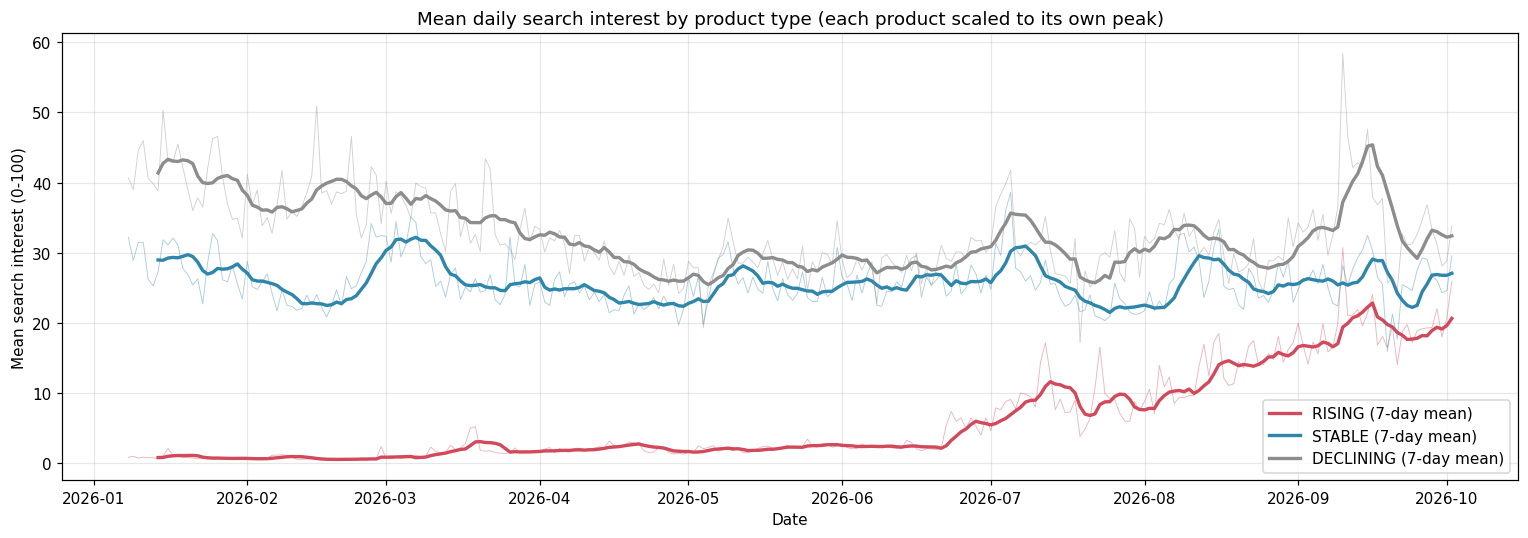

**Findings**

- Mean of the first 28 days vs the last 28 complete days: RISING 1 -> 20, STABLE 28 -> 26, DECLINING 40 -> 35.
- RISING products climb from near zero as launches arrive; their mean peaks on 2026-09-10.
- Means of relative series show shape, not market size; a type with many launches in one month will spike in that month.

In [4]:
if has(complete, "date", "search_interest", "product_type"):
    m = complete.groupby(["date", "product_type"])["search_interest"].mean().unstack().reindex(columns=TYPES)
    fig, ax = plt.subplots(figsize=(14, 5))
    for t in TYPES:
        if t in m:
            ax.plot(m.index, m[t], color=COLORS[t], lw=0.6, alpha=0.4)
            ax.plot(m.index, m[t].rolling(7, min_periods=7).mean(), color=COLORS[t], lw=2.2, label=f"{t} (7-day mean)")
    ax.set_title("Mean daily search interest by product type (each product scaled to its own peak)")
    ax.set_xlabel("Date")
    ax.set_ylabel("Mean search interest (0-100)")
    ax.legend()
    save(fig, "eda_full_03_mean_interest_by_type.png")
    first, last = m.iloc[:28].mean(), m.iloc[-28:].mean()
    rising_peak = m["RISING"].idxmax().date() if "RISING" in m else None
    findings("Mean of the first 28 days vs the last 28 complete days: " +
             ", ".join(f"{t} {first[t]:.0f} -> {last[t]:.0f}" for t in TYPES if t in m) + ".",
             f"RISING products climb from near zero as launches arrive; their mean peaks on {rising_peak}.",
             "Means of relative series show shape, not market size; a type with many launches in one month will spike in that month.")

## 4. Ten most prominent peaks

**Business question:** which products had the sharpest demand spikes, and what did those spikes look like?

Every Trends series peaks at exactly 100 (each product is scaled to its own peak), so "top 10 by peak" would be arbitrary. Instead this ranks products by **peak prominence**: the peak divided by the product's mean over the window. A high ratio means a short, sharp spike.

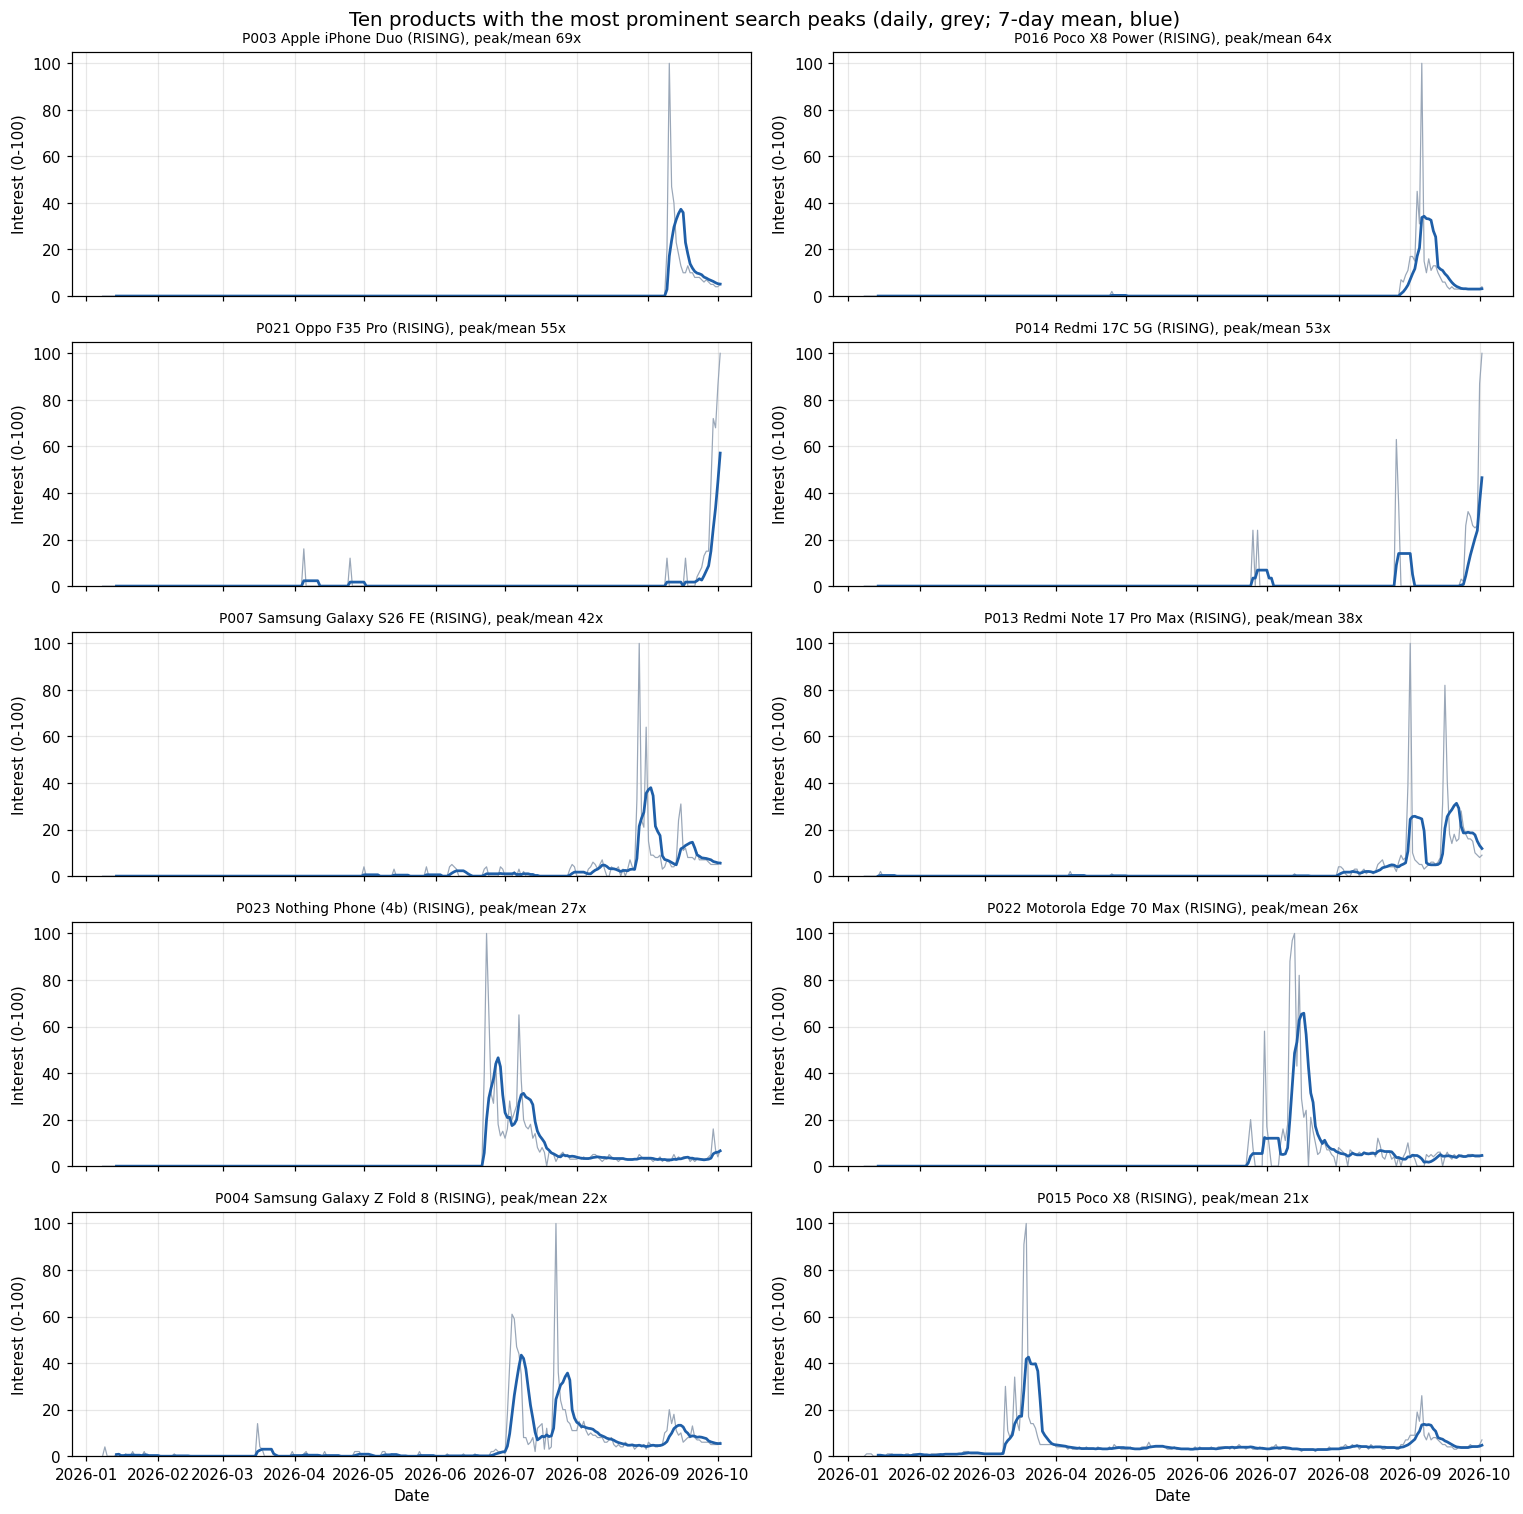

**Findings**

- Most prominent peaks: P003 (69x, 2026-09-10), P016 (64x, 2026-09-06), P021 (55x, 2026-10-02), P014 (53x, 2026-10-02), P007 (42x, 2026-08-28).
- Product types among the top 10: RISING 10.
- Peaks coincide with launch or announcement days and fade within days to weeks, so the useful early-warning window is short.

In [5]:
if has(complete, "product_id", "date", "search_interest"):
    stats = complete.groupby("product_id")["search_interest"].agg(["max", "mean"])
    stats = stats[stats["mean"] > 0]
    stats["prominence"] = stats["max"] / stats["mean"]
    top = stats.sort_values("prominence", ascending=False).head(10)
    names = aligned.drop_duplicates("product_id").set_index("product_id")
    fig, axes = plt.subplots(5, 2, figsize=(14, 14), sharex=True)
    for ax, (pid, r) in zip(axes.flat, top.iterrows()):
        s = complete[complete["product_id"] == pid].set_index("date")["search_interest"]
        ax.plot(s.index, s, color="#9aa7b8", lw=0.8)
        ax.plot(s.index, s.rolling(7, min_periods=7).mean(), color="#1f5fa8", lw=1.8)
        ax.set_title(f"{pid} {names.loc[pid, 'product_name']} ({names.loc[pid, 'product_type']}), "
                     f"peak/mean {r['prominence']:.0f}x", fontsize=9)
        ax.set_ylabel("Interest (0-100)")
        ax.set_ylim(0, 105)
    for ax in axes[-1]:
        ax.set_xlabel("Date")
    fig.suptitle("Ten products with the most prominent search peaks (daily, grey; 7-day mean, blue)", fontsize=13)
    save(fig, "eda_full_04_top10_peaks.png")
    peak_days = complete.loc[complete.groupby("product_id")["search_interest"].idxmax()].set_index("product_id")["date"]
    types = names.loc[top.index, "product_type"].value_counts()
    findings("Most prominent peaks: " + ", ".join(f"{pid} ({r['prominence']:.0f}x, {peak_days[pid].date()})"
                                                for pid, r in top.head(5).iterrows()) + ".",
             f"Product types among the top 10: " + ", ".join(f"{t} {n}" for t, n in types.items()) + ".",
             "Peaks coincide with launch or announcement days and fade within days to weeks, so the useful early-warning window is short.")

## 5. YouTube on-target share by brand

**Business question:** for which brands does a YouTube search return videos about the exact model, rather than its siblings?

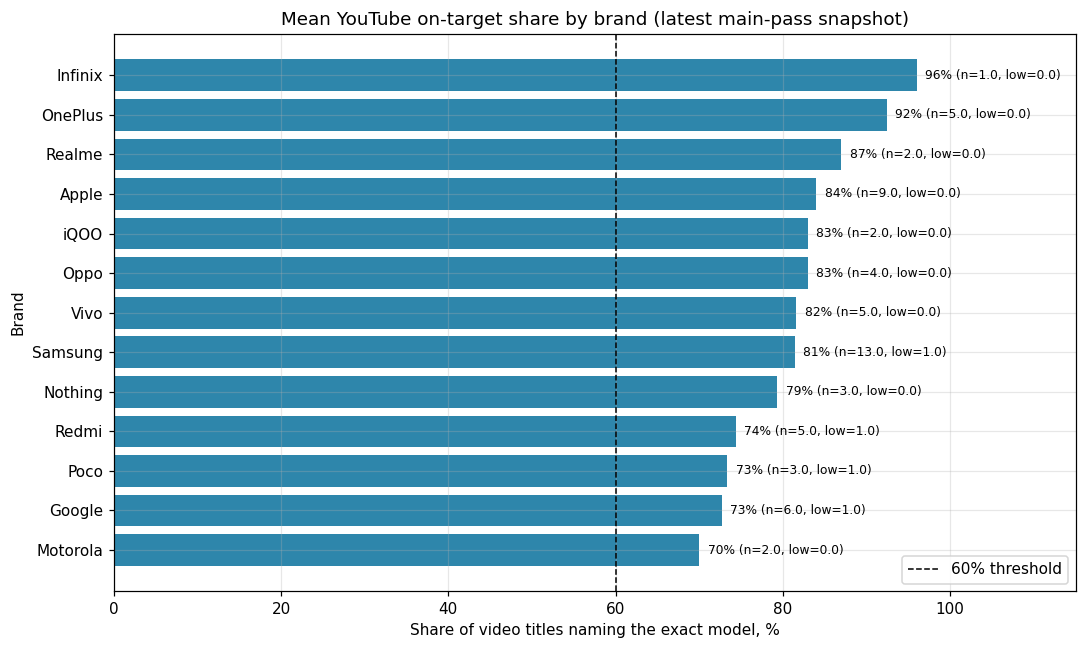

**Findings**

- Lowest brand averages: Motorola 70%, Google 73%, Poco 73%; highest: Infinix 96%, OnePlus 92%, Realme 87%.
- 4 products are below 60% on-target: P009 50%, P012 56%, P015 48%, P028 56%.
- Low shares come from sibling models sharing the search phrase (Pro/Max/Fusion variants); use the on-target columns for modelling.

In [6]:
if has(report, "brand", "on_target_share"):
    b = report.dropna(subset=["on_target_share"]).groupby("brand").agg(
        mean_share=("on_target_share", "mean"), products=("product_id", "count"),
        low=("low_on_target_share", lambda s: int((s == True).sum()))).sort_values("mean_share")
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(b.index, b["mean_share"] * 100, color=["#d1495b" if v < 60 else "#2e86ab" for v in b["mean_share"] * 100])
    for y, (brand, r) in enumerate(b.iterrows()):
        ax.text(r["mean_share"] * 100 + 1, y, f"{r['mean_share']:.0%} (n={r['products']}, low={r['low']})",
                va="center", fontsize=8)
    ax.axvline(60, color="black", ls="--", lw=1, label="60% threshold")
    ax.set_xlim(0, 115)
    ax.set_title("Mean YouTube on-target share by brand (latest main-pass snapshot)")
    ax.set_xlabel("Share of video titles naming the exact model, %")
    ax.set_ylabel("Brand")
    ax.legend(loc="lower right")
    save(fig, "eda_full_05_on_target_by_brand.png")
    lows = report[report["low_on_target_share"] == True]
    findings(f"Lowest brand averages: " + ", ".join(f"{i} {r.mean_share:.0%}" for i, r in b.head(3).iterrows()) +
             f"; highest: " + ", ".join(f"{i} {r.mean_share:.0%}" for i, r in b.tail(3).iloc[::-1].iterrows()) + ".",
             f"{len(lows)} products are below 60% on-target: " +
             (", ".join(f"{r.product_id} {r.on_target_share:.0%}" for r in lows.itertuples()) or "none") + ".",
             "Low shares come from sibling models sharing the search phrase (Pro/Max/Fusion variants); use the on-target columns for modelling.")

## 6. Comments collected per product

**Business question:** is there enough comment text per product for sentiment or topic analysis?

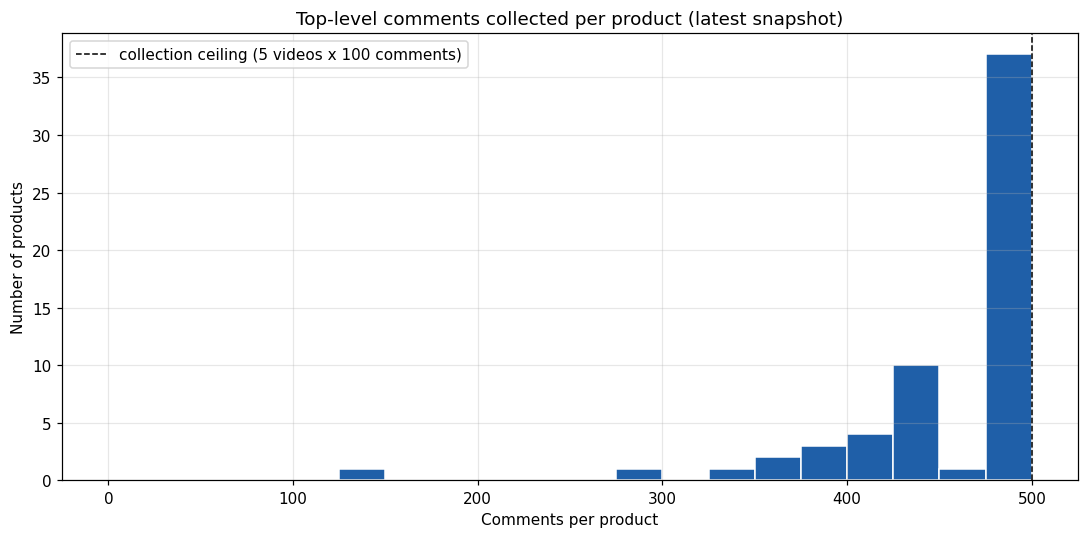

**Findings**

- 60 products; median 500 comments, range 147-500; 30 products hit the 500-comment ceiling.
- Products with fewer than 200 comments: P021.
- The ceiling is a collection limit (top 5 videos by views, 100 top-level comments each, no replies), not a measure of engagement.

In [7]:
if has(report, "youtube_comments"):
    c = report["youtube_comments"].dropna()
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(c, bins=np.arange(0, 525, 25), color="#1f5fa8", edgecolor="white")
    ax.axvline(500, color="black", ls="--", lw=1, label="collection ceiling (5 videos x 100 comments)")
    ax.set_title("Top-level comments collected per product (latest snapshot)")
    ax.set_xlabel("Comments per product")
    ax.set_ylabel("Number of products")
    ax.legend()
    save(fig, "eda_full_06_comments_per_product.png")
    findings(f"{len(c)} products; median {c.median():.0f} comments, range {c.min():.0f}-{c.max():.0f}; "
             f"{(c >= 500).sum()} products hit the 500-comment ceiling.",
             f"Products with fewer than 200 comments: " +
             (", ".join(report.loc[report['youtube_comments'] < 200, 'product_id']) or "none") + ".",
             "The ceiling is a collection limit (top 5 videos by views, 100 top-level comments each, no replies), not a measure of engagement.")

## 7. Comment length, emoji-only and non-English comments

**Business question:** how much usable text do comments carry, and how many need special handling before sentiment analysis?

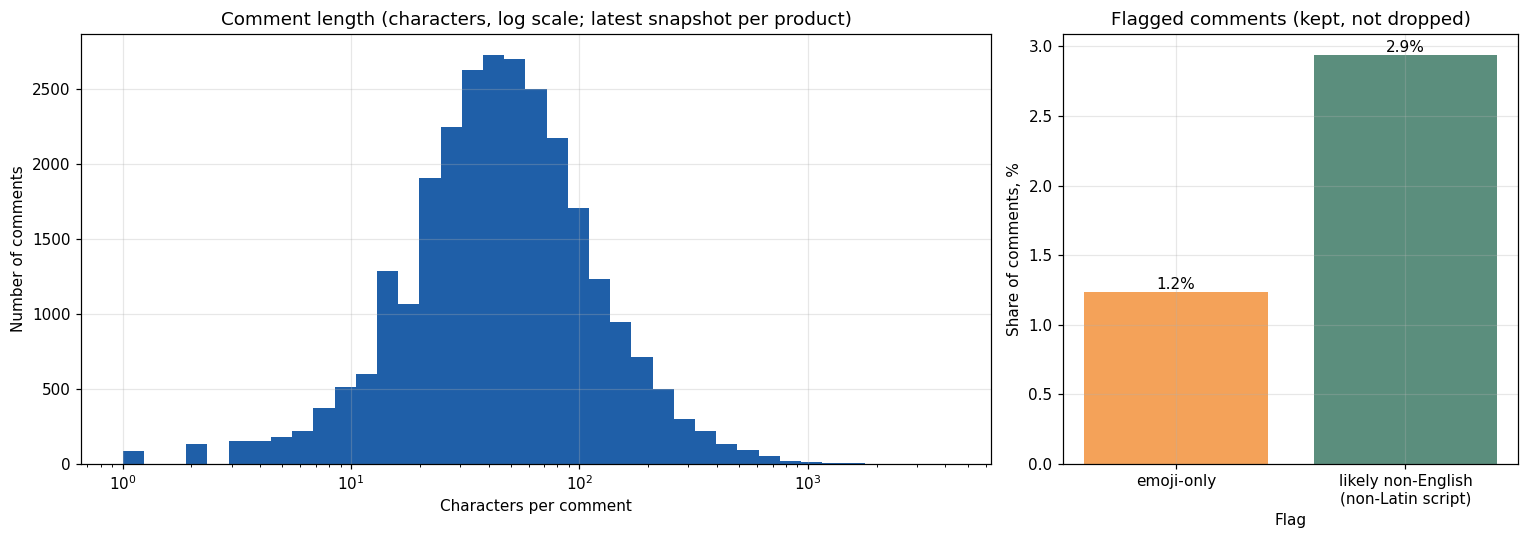

**Findings**

- 27,576 comments; median length 45 characters; 18% are 20 characters or shorter.
- 1.2% are emoji-only and 2.9% are in a non-Latin script (e.g. Devanagari, Tamil, Telugu); both are flagged, not dropped.
- The non-English flag looks at the script, not the language: Hinglish and other romanised Indian languages count as English, so an English-only sentiment model will misread a share of the 'English' comments.

In [8]:
if has(latest_comments, "text", "is_emoji_only", "likely_non_english"):
    lengths = latest_comments["text"].astype(str).str.len()
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [2, 1]})
    axes[0].hist(lengths, bins=np.logspace(0, np.log10(max(lengths.max(), 10)), 40), color="#1f5fa8")
    axes[0].set_xscale("log")
    axes[0].set_title("Comment length (characters, log scale; latest snapshot per product)")
    axes[0].set_xlabel("Characters per comment")
    axes[0].set_ylabel("Number of comments")
    shares = pd.Series({"emoji-only": latest_comments["is_emoji_only"].astype(bool).mean() * 100,
                        "likely non-English\n(non-Latin script)": latest_comments["likely_non_english"].astype(bool).mean() * 100})
    axes[1].bar(shares.index, shares.values, color=["#f4a259", "#5b8e7d"])
    for x, v in enumerate(shares.values):
        axes[1].text(x, v, f"{v:.1f}%", ha="center", va="bottom")
    axes[1].set_title("Flagged comments (kept, not dropped)")
    axes[1].set_xlabel("Flag")
    axes[1].set_ylabel("Share of comments, %")
    save(fig, "eda_full_07_comment_length_flags.png")
    findings(f"{len(latest_comments):,} comments; median length {lengths.median():.0f} characters; "
             f"{(lengths <= 20).mean():.0%} are 20 characters or shorter.",
             f"{shares.iloc[0]:.1f}% are emoji-only and {shares.iloc[1]:.1f}% are in a non-Latin script "
             "(e.g. Devanagari, Tamil, Telugu); both are flagged, not dropped.",
             "The non-English flag looks at the script, not the language: Hinglish and other romanised Indian languages "
             "count as English, so an English-only sentiment model will misread a share of the 'English' comments.")

## 8. YouTube vs Google Trends overlap and coverage

**Business question:** how many days have both a Trends value and a YouTube observation, and is that enough to relate the two over time?

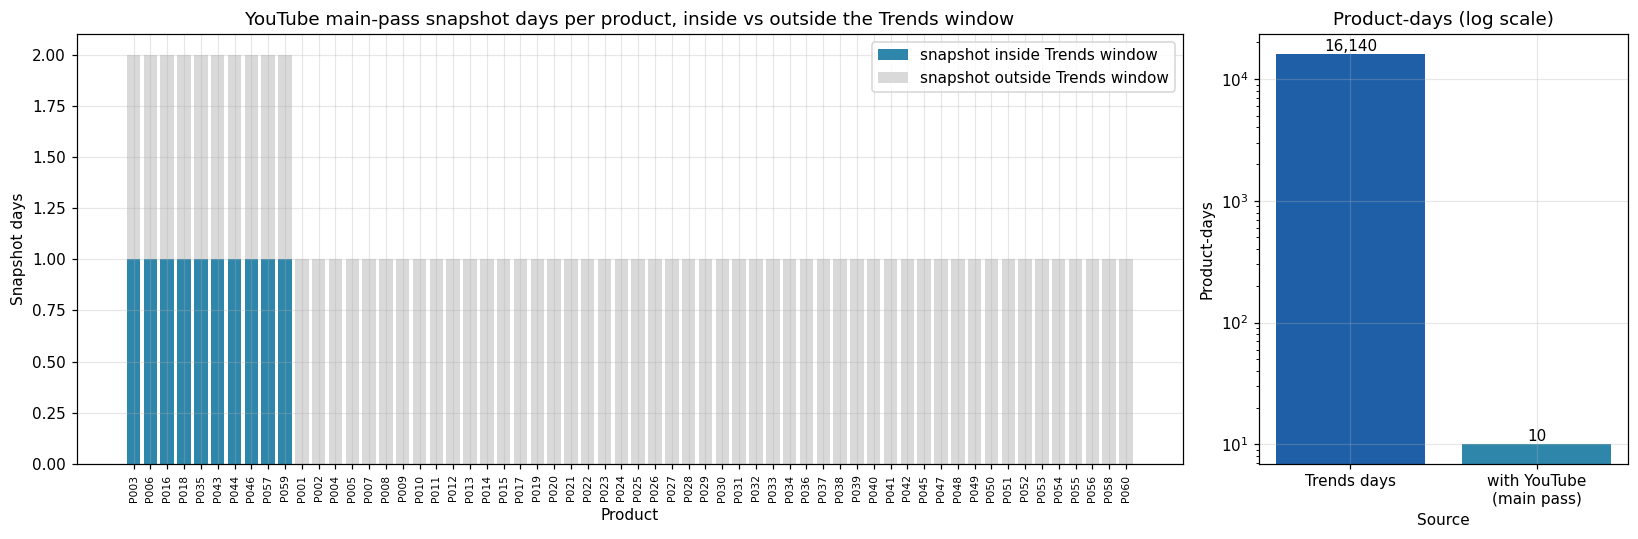

**Findings**

- Only **10 of 16,140 product-days (0.06%)** have both a Trends value and a YouTube main-pass observation; 60 YouTube snapshot days fall outside the Trends window.
- YouTube snapshot dates so far: 2026-10-03, 2026-10-04; the Trends window ends on 2026-10-03.
- **The overlap is too thin to relate YouTube and Trends over time.** It grows only with scheduled YouTube snapshots and a Trends refresh whose window covers those dates (re-pull the latest batch; never stack pulls).

In [9]:
if has(coverage, "product_id", "trends_days", "youtube_matched", "youtube_unmatched"):
    cov = coverage[coverage["product_id"] != "ALL"].copy()
    cov = cov.sort_values(["youtube_matched", "product_id"], ascending=[False, True])
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={"width_ratios": [3, 1]})
    axes[0].bar(cov["product_id"], cov["youtube_matched"], color="#2e86ab", label="snapshot inside Trends window")
    axes[0].bar(cov["product_id"], cov["youtube_unmatched"], bottom=cov["youtube_matched"], color="#d9d9d9",
                label="snapshot outside Trends window")
    axes[0].set_title("YouTube main-pass snapshot days per product, inside vs outside the Trends window")
    axes[0].set_xlabel("Product")
    axes[0].set_ylabel("Snapshot days")
    axes[0].tick_params(axis="x", rotation=90, labelsize=7)
    axes[0].legend()
    total = coverage[coverage["product_id"] == "ALL"].iloc[0] if (coverage["product_id"] == "ALL").any() else cov.sum(numeric_only=True)
    trend_days = int(cov["trends_days"].sum())
    matched = int(cov["youtube_matched"].sum())
    axes[1].bar(["Trends days", "with YouTube\n(main pass)"], [trend_days, matched], color=["#1f5fa8", "#2e86ab"])
    axes[1].set_yscale("log")
    for x, v in enumerate([trend_days, matched]):
        axes[1].text(x, v, f"{v:,}", ha="center", va="bottom")
    axes[1].set_title("Product-days (log scale)")
    axes[1].set_xlabel("Source")
    axes[1].set_ylabel("Product-days")
    save(fig, "eda_full_08_overlap_coverage.png")
    snap_dates = sorted(daily["snapshot_date"].unique()) if has(daily, "snapshot_date") else []
    findings(f"Only **{matched} of {trend_days:,} product-days ({matched / trend_days:.2%})** have both a Trends value "
             f"and a YouTube main-pass observation; {int(cov['youtube_unmatched'].sum())} YouTube snapshot days fall "
             f"outside the Trends window.",
             f"YouTube snapshot dates so far: {', '.join(snap_dates) or 'none'}; the Trends window ends on "
             f"{aligned['date'].max().date() if not aligned.empty else 'n/a'}.",
             "**The overlap is too thin to relate YouTube and Trends over time.** It grows only with scheduled YouTube "
             "snapshots and a Trends refresh whose window covers those dates (re-pull the latest batch; never stack pulls).")

## 9. Views vs comments across products

**Business question:** does audience size (views) translate proportionally into discussion (comments) across products?

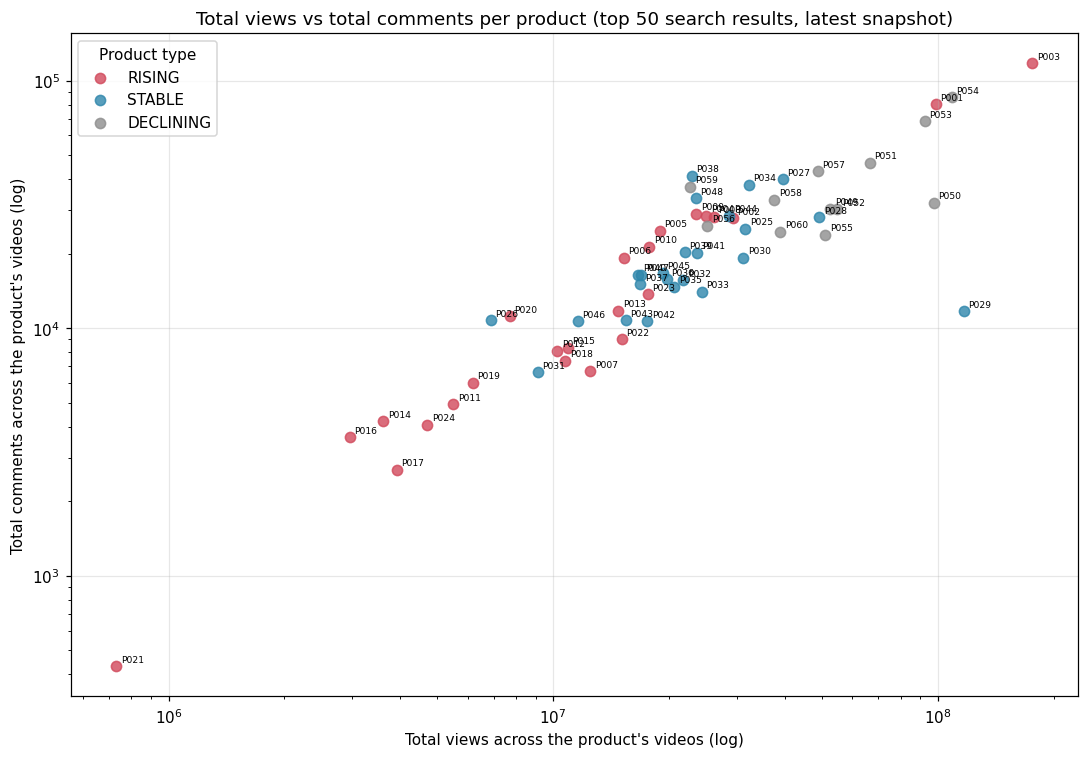

**Findings**

- 60 products; views and comments are strongly rank-correlated (Spearman 0.87).
- Comments per 1,000 views: median 0.83, highest P038 (1.79).
- Totals cover a relevance-ranked set of at most 50 videos, including sibling-model videos; the on-target totals in `full_report.csv` are the modelling versions.

In [10]:
if has(report, "video_views_total", "product_type") and has(daily, "video_comments_total"):
    latest_daily = daily[daily["snapshot_date"] == daily.groupby("product_id")["snapshot_date"].transform("max")]
    d = latest_daily.merge(report[["product_id", "product_type"]], on="product_id")
    d = d[(d["video_views_total"] > 0) & (d["video_comments_total"] > 0)]
    fig, ax = plt.subplots(figsize=(10, 7))
    for t in TYPES:
        g = d[d["product_type"] == t]
        ax.scatter(g["video_views_total"], g["video_comments_total"], s=45, color=COLORS[t], label=t, alpha=0.8)
    for _, r in d.iterrows():
        ax.annotate(r["product_id"], (r["video_views_total"], r["video_comments_total"]), xytext=(3, 3),
                    textcoords="offset points", fontsize=6)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_title("Total views vs total comments per product (top 50 search results, latest snapshot)")
    ax.set_xlabel("Total views across the product's videos (log)")
    ax.set_ylabel("Total comments across the product's videos (log)")
    ax.legend(title="Product type")
    save(fig, "eda_full_09_views_vs_comments.png")
    rho = d["video_views_total"].corr(d["video_comments_total"], method="spearman")
    ratio = (d["video_comments_total"] / d["video_views_total"] * 1000)
    hi = d.loc[ratio.idxmax()]
    findings(f"{len(d)} products; views and comments are strongly rank-correlated (Spearman {rho:.2f}).",
             f"Comments per 1,000 views: median {ratio.median():.2f}, highest {hi['product_id']} ({ratio.max():.2f}).",
             "Totals cover a relevance-ranked set of at most 50 videos, including sibling-model videos; "
             "the on-target totals in `full_report.csv` are the modelling versions.")

## Limitations
- Trends values are relative to each product's own peak; pytrends cannot distinguish "<1" from 0; the last day is provisional.
- YouTube has one main-pass snapshot per product (two for the 10 pilot products), so there is no YouTube time series yet.
- Nothing here is a model feature or the project's surge label.